In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,DualTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/ADNI/normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/ADNI/ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/ADNI/NC_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #151
print(count_no) #211
print(count_mci) #475

151
211
475


In [4]:
# 旧的 raw BIO/EHR 特征提取已废弃，统一使用 preprocess_data() + target_cols 提取。
pass

In [5]:
# 旧的 raw BIO/EHR 特征提取已废弃，统一使用 preprocess_data() + target_cols 提取。
pass

In [6]:
# 旧的 raw BIO/EHR 特征提取已废弃，统一使用 preprocess_data() + target_cols 提取。
pass

In [7]:
# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        extracted_row = [row[idx] for idx in target_cols]
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                if math.isnan(val):
                    val = np.nan
            except ValueError:
                val = np.nan
            numerical_row.append(val)
        processed_data.append(numerical_row)
    return np.array(processed_data, dtype=float)

# 加权算值函数 (保留你的原始定义)
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [8]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [9]:
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0', 'ind':'3', 'ans':'4'}

ehr_cols = [2, 3, 4, 5, 6] + list(range(57, 66))

# 1. 提取脱敏后的 EHR 数组 (内部已通过 replace_dict 转换为数值)
ad_EHR = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_EHR = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_EHR = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor (无需外部线性层)
ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

# 3. 打印结果 (预期输出类似: torch.Size([151, 14]))
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([151, 14])
normal.EHR---> torch.Size([211, 14])
mci.EHR---> torch.Size([475, 14])


In [10]:
#医学图像
nii = CNN_3D(num_class=1)
nii= nii.to(device)
all_ad = 'E:/code/ADNI/ad_nii_KG/'
all_normal = 'E:/code/ADNI/normal_nii_kg/'
all_mci = 'E:/code/ADNI/NC_nii_KG/'
dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

In [11]:
# 统计模型参数量和算力损耗
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("CNN_3D trainable 参数量:", count_trainable_params(nii))

try:
    import torch
    try:
        from fvcore.nn import FlopCountAnalysis
        sample_input = torch.randn(1, 1, 64, 64, 64, device=device)
        flop = FlopCountAnalysis(nii, sample_input)
        print("CNN_3D FLOPs:", flop.total(), "=", flop.total().item() / 1e9, "GFLOPs")
    except Exception:
        try:
            from thop import profile
            sample_input = torch.randn(1, 1, 64, 64, 64, device=device)
            macs, params = profile(nii, inputs=(sample_input,), verbose=False)
            print("CNN_3D MACs:", macs, "=", macs / 1e9, "GMACs")
            print("CNN_3D FLOPs:", 2 * macs, "=", 2 * macs / 1e9, "GFLOPs")
        except Exception as e:
            print("未安装 fvcore/thop，无法自动估算 FLOPs/MACs。")
            print("详细错误:", e)
except Exception as e:
    print("算力统计失败：", e)


CNN_3D trainable 参数量: 8403041
CNN_3D MACs: 574619712.0 = 0.574619712 GMACs
CNN_3D FLOPs: 1149239424.0 = 1.149239424 GFLOPs


In [12]:
# 将数据移动到 CPU
ad_EHR = ad_EHR.cpu()
mci_EHR = mci_EHR.cpu()
normal_EHR = normal_EHR.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()
X_ad = torch.cat([ad_EHR, ad_output], dim=1)  
X_mci = torch.cat([mci_EHR, mci_output], dim=1)  
X_normal = torch.cat([normal_EHR, normal_output], dim=1)  
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()
X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(),
    test_size=0.25,
    stratify=y.numpy(),
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
)

In [13]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # 获取预测概率和预测类别
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [17]:
model = DualTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# 平衡类别权重，避免模型偏向多数类
# 这里自动根据当前标签分布计算权重
label_counts = torch.tensor([ (y == 0).sum(), (y == 1).sum(), (y == 2).sum() ], dtype=torch.float32)
class_weights = (1.0 / label_counts).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print('Class weights:', class_weights.cpu().numpy())

Class weights: [0.00473934 0.00210526 0.00662252]


In [37]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(201):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    if epoch % 10 == 0: print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

Epoch 000 | Train Loss: 1.0602 | Train AUC: 0.6078 | Test Loss: 1.0647 | Test AUC: 0.5802
--------------------------------------------------------------------------------
Epoch 001 | Train Loss: 1.0610 | Train AUC: 0.6129 | Test Loss: 1.1213 | Test AUC: 0.5355
--------------------------------------------------------------------------------
Epoch 002 | Train Loss: 1.0660 | Train AUC: 0.6046 | Test Loss: 1.0775 | Test AUC: 0.5543
--------------------------------------------------------------------------------
Epoch 003 | Train Loss: 1.0515 | Train AUC: 0.6102 | Test Loss: 1.0693 | Test AUC: 0.5698
--------------------------------------------------------------------------------
Epoch 004 | Train Loss: 1.0851 | Train AUC: 0.5832 | Test Loss: 1.0729 | Test AUC: 0.5598
--------------------------------------------------------------------------------
Epoch 005 | Train Loss: 1.0473 | Train AUC: 0.6199 | Test Loss: 1.0705 | Test AUC: 0.5615
-------------------------------------------------------

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 028 | Train Loss: 1.0781 | Train AUC: 0.5892 | Test Loss: 1.3310 | Test AUC: 0.5177
--------------------------------------------------------------------------------
Epoch 029 | Train Loss: 1.0798 | Train AUC: 0.5708 | Test Loss: 1.1030 | Test AUC: 0.5477
--------------------------------------------------------------------------------
Epoch 030 | Train Loss: 1.0667 | Train AUC: 0.5966 | Test Loss: 1.1616 | Test AUC: 0.5027
--------------------------------------------------------------------------------
Epoch 031 | Train Loss: 1.0572 | Train AUC: 0.6131 | Test Loss: 1.0945 | Test AUC: 0.5327
--------------------------------------------------------------------------------
Epoch 032 | Train Loss: 1.0708 | Train AUC: 0.5959 | Test Loss: 1.1259 | Test AUC: 0.5235
--------------------------------------------------------------------------------
Epoch 033 | Train Loss: 1.0646 | Train AUC: 0.5964 | Test Loss: 1.0853 | Test AUC: 0.5371
-------------------------------------------------------

d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 075 | Train Loss: 1.0549 | Train AUC: 0.6179 | Test Loss: 1.3674 | Test AUC: 0.4955
--------------------------------------------------------------------------------
Epoch 076 | Train Loss: 1.0602 | Train AUC: 0.5920 | Test Loss: 1.0702 | Test AUC: 0.5655
--------------------------------------------------------------------------------
Epoch 077 | Train Loss: 1.0637 | Train AUC: 0.5926 | Test Loss: 1.0648 | Test AUC: 0.5815
--------------------------------------------------------------------------------
Epoch 078 | Train Loss: 1.0678 | Train AUC: 0.5977 | Test Loss: 1.0644 | Test AUC: 0.5788
--------------------------------------------------------------------------------
Epoch 079 | Train Loss: 1.0529 | Train AUC: 0.6190 | Test Loss: 1.0763 | Test AUC: 0.5759
--------------------------------------------------------------------------------
Epoch 080 | Train Loss: 1.0646 | Train AUC: 0.6128 | Test Loss: 1.1460 | Test AUC: 0.5276
-------------------------------------------------------

In [38]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.5732
Precision: 0.4737
Recall:    0.4717
F1 Score:  0.4531
AUC-ROC:   0.6400


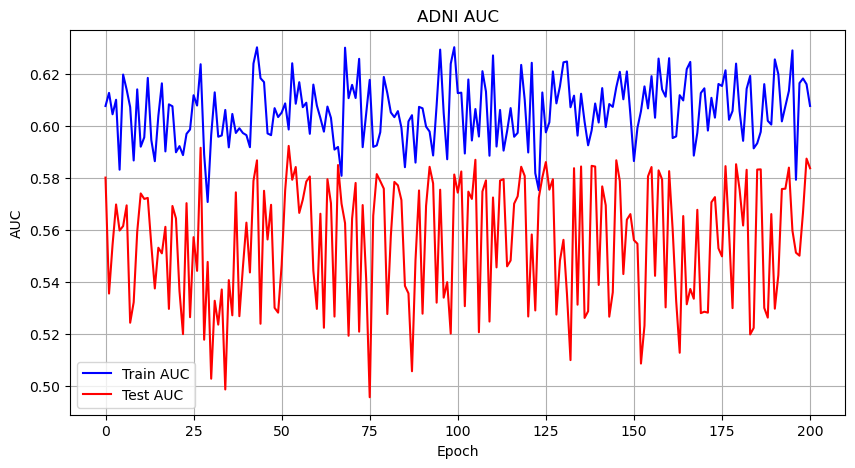

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("ADNI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('ADNI_Baseline_Dual_plot.png', dpi=300)
plt.close()

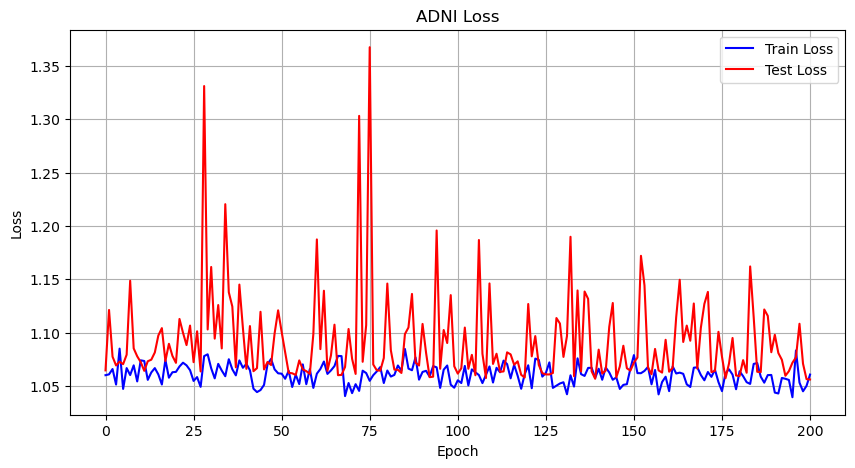

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("ADNI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('ADNI_Baseline_Dual_plot.png', dpi=300)
plt.close()

In [41]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.33      0.42      0.37        53
         MCI       0.60      0.61      0.61       119
          AD       0.22      0.13      0.16        38

    accuracy                           0.48       210
   macro avg       0.38      0.39      0.38       210
weighted avg       0.47      0.48      0.47       210

Confusion Matrix:
[[22 26  5]
 [33 73 13]
 [11 22  5]]
AUC Score (Ovr): 0.5838
